# Simple Grid World: Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [690]:
import numpy as np
np.set_printoptions(precision=2)

In [691]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define an Empty 5x5 Grid 

A maze without walls. The step cost is 1. The start is (0,0) and
the goal (+100 reward) is (4,4).
This is the ideal problem for a linear approximation of the Q-function
using the x/y location as state features.

In [692]:
from gym_classics.envs.abstract.gridworld import Gridworld

class EmptyGridworld(Gridworld):
    layout = """
|    G|
|     |
|     |
|     |
|S    |
"""

    def __init__(self):
        super().__init__(self.layout)

    def _reward(self, state, action, next_state):
        if state in self._goals:
            return 0.0
        return {(4, 4): 100.0}.get(next_state, -1)

    def _done(self, state, action, next_state):
        return next_state in self._goals   

gym.register('EmptyGridworld-v1', entry_point=EmptyGridworld)

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment EmptyGridworld-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


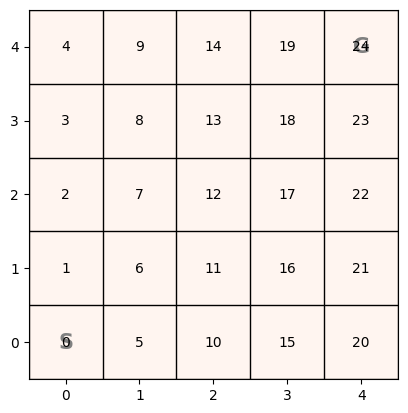

In [693]:
gym_env = gym.make('EmptyGridworld-v1')
#gym_env = gym.make('ClassicGridworld-v1')

env = gym_env.unwrapped

env.image()

In [694]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

sample_episode(env, max_len=10000)

[(0, 1, -1, 5),
 (5, 3, -1, 0),
 (0, 0, -1, 1),
 (1, 3, -1, 1),
 (1, 3, -1, 1),
 (1, 3, -1, 1),
 (1, 3, -1, 1),
 (1, 0, -1, 2),
 (2, 0, -1, 3),
 (3, 0, -1, 4),
 (4, 1, -1, 9),
 (9, 0, -1, 9),
 (9, 0, -1, 9),
 (9, 2, -1, 8),
 (8, 3, -1, 3),
 (3, 3, -1, 3),
 (3, 2, -1, 2),
 (2, 3, -1, 2),
 (2, 2, -1, 1),
 (1, 3, -1, 1),
 (1, 0, -1, 2),
 (2, 0, -1, 3),
 (3, 2, -1, 2),
 (2, 0, -1, 3),
 (3, 2, -1, 2),
 (2, 1, -1, 7),
 (7, 1, -1, 12),
 (12, 0, -1, 13),
 (13, 3, -1, 8),
 (8, 3, -1, 3),
 (3, 2, -1, 2),
 (2, 2, -1, 1),
 (1, 2, -1, 0),
 (0, 0, -1, 1),
 (1, 2, -1, 0),
 (0, 3, -1, 0),
 (0, 2, -1, 0),
 (0, 1, -1, 5),
 (5, 3, -1, 0),
 (0, 3, -1, 0),
 (0, 3, -1, 0),
 (0, 3, -1, 0),
 (0, 1, -1, 5),
 (5, 3, -1, 0),
 (0, 2, -1, 0),
 (0, 2, -1, 0),
 (0, 3, -1, 0),
 (0, 0, -1, 1),
 (1, 0, -1, 2),
 (2, 1, -1, 7),
 (7, 0, -1, 8),
 (8, 0, -1, 9),
 (9, 1, -1, 14),
 (14, 3, -1, 9),
 (9, 0, -1, 9),
 (9, 2, -1, 8),
 (8, 3, -1, 3),
 (3, 0, -1, 4),
 (4, 2, -1, 3),
 (3, 1, -1, 8),
 (8, 2, -1, 7),
 (7, 3, -1, 2),
 (

## State Features

We use here simply the x and y-coordinates as the state feature vector $\mathbf{x}(s)$. We also add an intercept (a 1) to the beginning so we end up with a 3-dimensional state feature.

`[intercept (always 1), x, y]`


In [695]:
def state_features(s):
    coord = env.decode(s)
    return np.concatenate([np.array([1]), np.array(coord)])

In [696]:
display(state_features(0))
display(state_features(1))

array([1, 0, 0])

array([1, 0, 1])

Linear approximation of the value function just mean we calculate a weighted sum of the state feature components:

$\hat{v}(s,\mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)$, 

where $\mathbf{w}$ is the weight vector we want to learn.

In [697]:
def v_hat(s, w):
    x_s = state_features(s)
    return np.dot(w, x_s)

For example, I manually define here a weight vector.

In [698]:
w = np.array([1, 5, 20])

This means the smallest value at $(0,0)$ is the intercept of 1 and the value function increases by 5 for every step in the x direction and by
20 in the y direction.

In [699]:

print (f" v_hat((0,0), w) = {v_hat(env.encode((0,0)), w)}")
print (f" v_hat((1,1), w) = {v_hat(env.encode((1,1)), w)}")

 v_hat((0,0), w) = 1
 v_hat((1,1), w) = 26


Here is the value function for the weights.

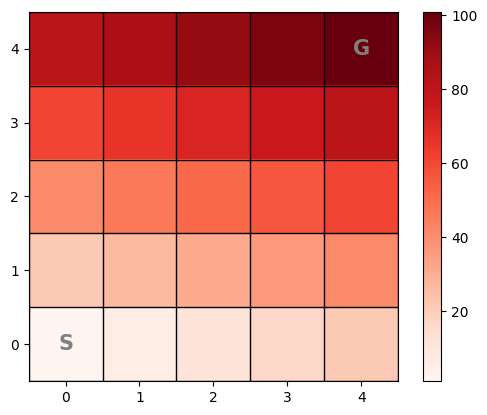

In [700]:
V = np.array([v_hat(s, w) for s in range(env.observation_space.n)])
env.image(V)

We can visualize the manually created value function using contours.

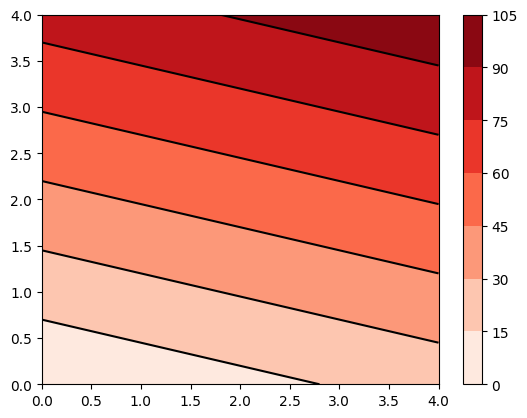

In [701]:
from matplotlib import pyplot as plt

def v_hat_grid(x, y, w):
    return np.dot(w, [1, x, y])

x = np.linspace(0, 4, 100)
y = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x, y)

Z = np.array([v_hat_grid(x, y, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

plt.contourf(X, Y, Z, cmap='Reds')
plt.colorbar()
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()

# Estimation: Learning w for a given Policy 


We want to minimize the mean square value error: $\overline{VE} = \sum_{s\in \mathcal{S}} \mu(s) [v_\pi - \hat{v}(s, \mathbf{w})]^2$

This leads to:

* SGD update: $\mathbf{w}_{t+1} = \mathbf{w}_t + \alpha (U_t - \hat{v}(S_t, \mathbf{w}_t)) \mathbf{x}(S_t)$
* Gradient: $\nabla \hat{v}(s, \mathbf{w}) = \mathbf{x}(s)$


We could use the gradient Monte Carlo algorithm, but we show here the
Semi-Gradient TD(0) Algorithm with Linear Function Approximation.



![Semi-Gradient TD(0)](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_TD0.png)

In [702]:
def semi_gradient_TD0_estimation(env, policy, n, alpha, gamma, max_episode_length=100, verbose = True):
    assert isinstance(env, gym.Env), "env must be an instance of gym.Env"
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"
    
    w = np.zeros(state_features(0).shape[0])  # Initialize weights (intercept + x and y)

    for episode in range(n):
        state, _ = env.reset()
        done = False

        i = 0
        while not done and i < max_episode_length:
            action = policy[state]  # follow policy
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Semi-gradient TD(0) update
            # Note: v_hat(terminal, w) needs to be 0
            if terminated:
                w += alpha * (reward - v_hat(state, w)) * state_features(state)    
            else: 
                w += alpha * (reward + gamma * v_hat(next_state, w) - v_hat(state, w)) * state_features(state)
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            i += 1

    return w

I will manually create a policy to evaluate.

In [703]:
pol = np.full(env.observation_space.n, env.encode_action('up'))
pol[[4, 9, 14, 19]] = env.encode_action('right')
pol

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0])

In [704]:
w = semi_gradient_TD0_estimation(env, pol, n=5000, alpha=0.01, gamma=1, verbose=False)
w

array([93.,  1.,  1.])

It learns correctly that increasing x or y increases the value by 1 (the step cost) and that we start in $(0,0)$ with a value of 93.

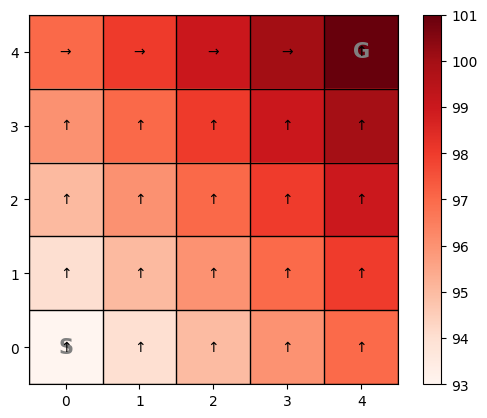

In [705]:
V = np.array([v_hat(s, w) for s in range(env.observation_space.n)])
env.image(V, policy=pol)

In [706]:
env.print(V)

 +97.00   +98.00   +99.00  +100.00  +101.00  
 +96.00   +97.00   +98.00   +99.00  +100.00  
 +95.00   +96.00   +97.00   +98.00   +99.00  
 +94.00   +95.00   +96.00   +97.00   +98.00  
 +93.00   +94.00   +95.00   +96.00   +97.00  


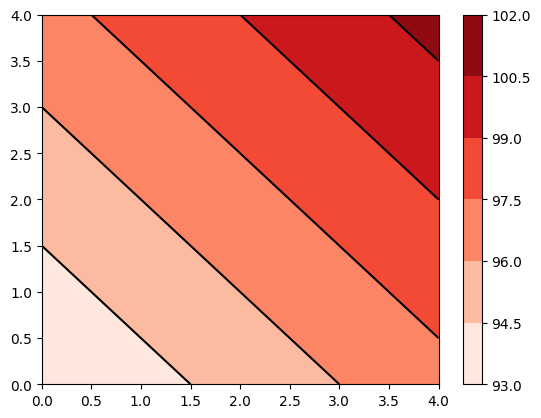

In [707]:
from matplotlib import pyplot as plt

def v_hat_grid(x, y, w):
    return np.dot(w, [1, x, y])

x = np.linspace(0, 4, 100)
y = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x, y)

Z = np.array([v_hat_grid(x, y, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

plt.contourf(X, Y, Z, cmap='Reds')
plt.colorbar()
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()

# Control: Semi-Gradient Sarsa

This is an on-policy control algorithm which has the following implications:

* It is required that the algorithm keeps exploring. We accomplish that by using an $\epsilon$-greedy. 
* This means we will not find the optimal deterministic policy, but the best $\epsilon$-greedy policy and its approximate value function.


![Semi-Gradient Sarsa](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_SARSA.png)

To construct a linear state-action approximation function is a little more tricky. [Geramifard et al. (2013)](https://doi.org/10.1561/2200000042) suggest to use a state feature vectors to construct the complete state-action feature vector. It uses one shared intercept and then for each action a state feature component.
In our case we get a $w$ vectors of length 1 intercept + 4 actions $\times$ 2 coordinate values = 9. Here is the layout for the weight vector $\mathbf{w}$:

`[intercept, x_action0, y_action0, x_action1, y_action1, x_action2, y_action2, x_action3, y_action3]`

Only the intercept and the weights belonging to the action are used.

In [708]:
# choose intercept at 0 and the action-specific weights so we end up with 3 active weights.
def active_weights(a):
    return [0, a * 2 + 1, a * 2 + 2]

active_weights(1)

[0, 3, 4]

In [709]:
def q_hat(s, a, w): 
    return np.dot(w[active_weights(a)], state_features(s))

In [710]:
w = np.array([1,2,2,3,3,4,4,5,5])

# state 7 is (2,1): for action 2 this should be 1 (intercept) + 2*4+1*4 = 13
q_hat(7, 2, w)

np.int64(13)

In [711]:
def semi_gradient_Sarsa(env, n, epsilon, alpha, gamma, w = None, max_episode_length=100, verbose = True):
    assert isinstance(env, gym.Env), "env must be an instance of gym.Env"
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert epsilon >=0 and epsilon <=1, "Epsilon must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"

    if w is None:
        w = np.zeros(9)  # Initialize weights (intercept + action weights)

    # helper used later
    def epsilon_greedy_action(state, epsilon):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        else:
            q_values = [q_hat(state, a, w) for a in range(env.action_space.n)]
            return np.argmax(q_values)
    
    for episode in range(n):
        state, _ = env.reset()
        action = epsilon_greedy_action(state, epsilon)
        done = False

        i = 0
        while not done and i < max_episode_length:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            if terminated:
                next_action = None
                w[active_weights(action)] += alpha * (reward - q_hat(state, action, w)) * state_features(state)
                
            else:
                next_action = epsilon_greedy_action(next_state, epsilon)
                w[active_weights(action)] += alpha * (reward + gamma * q_hat(next_state, next_action, w) - q_hat(state, action, w)) * state_features(state)
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            action = next_action
            i += 1

    return w  
    

### Tests With Different Learning Rates 

In [712]:
# helper to visualize the learned policy and value function 
def plot_w(w, title=None):
    Q = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    
    # discourage leaving the grid for tie breaking. This is important because the empty maze has a perfectly symmetric value function.
    ids = env.to_matrix()
    Q[ids[:,-1],env.encode_action("right")] -= .1
    Q[ids[:,0],env.encode_action("left")] -= .1
    Q[ids[0,:],env.encode_action("down")] -= .1
    Q[ids[-1,:],env.encode_action("up")] -= .1
    
    V = np.max(Q, axis=1)
    pol = np.argmax(Q, axis=1)
    env.image(V, policy=pol, title=title)
    
    return Q, V, pol

In [713]:
env.to_matrix()


array([[ 0,  5, 10, 15, 20],
       [ 1,  6, 11, 16, 21],
       [ 2,  7, 12, 17, 22],
       [ 3,  8, 13, 18, 23],
       [ 4,  9, 14, 19, 24]])

Convergence is an issue with semi-gradient methods and heavily depends on the choice of the learning rate.

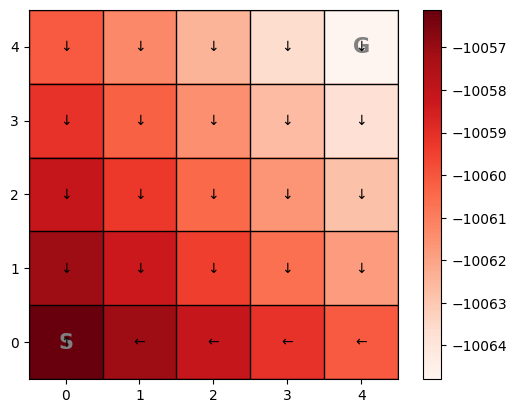

(array([[-10056.11, -10056.11, -10056.21, -10056.21],
        [-10059.64, -10058.86, -10057.11, -10058.32],
        [-10063.16, -10061.61, -10058.11, -10060.43],
        [-10066.68, -10064.36, -10059.11, -10062.53],
        [-10070.31, -10067.1 , -10060.11, -10064.64],
        [-10058.68, -10058.78, -10057.38, -10057.11],
        [-10062.2 , -10061.52, -10058.28, -10059.22],
        [-10065.72, -10064.27, -10059.28, -10061.32],
        [-10069.25, -10067.02, -10060.28, -10063.43],
        [-10072.87, -10069.77, -10061.28, -10065.54],
        [-10061.24, -10061.44, -10058.56, -10058.11],
        [-10064.76, -10064.19, -10059.46, -10060.22],
        [-10068.29, -10066.93, -10060.45, -10062.32],
        [-10071.81, -10069.68, -10061.45, -10064.43],
        [-10075.43, -10072.43, -10062.45, -10066.54],
        [-10063.8 , -10064.1 , -10059.73, -10059.11],
        [-10067.33, -10066.85, -10060.63, -10061.21],
        [-10070.85, -10069.6 , -10061.63, -10063.32],
        [-10074.37, -10072.3

In [714]:
w = semi_gradient_Sarsa(env, n=1000, epsilon=0.1, alpha=0.1, gamma=1, verbose=False)
plot_w(w)

Learning most likely did not converge! We need to reduce the learning rate.

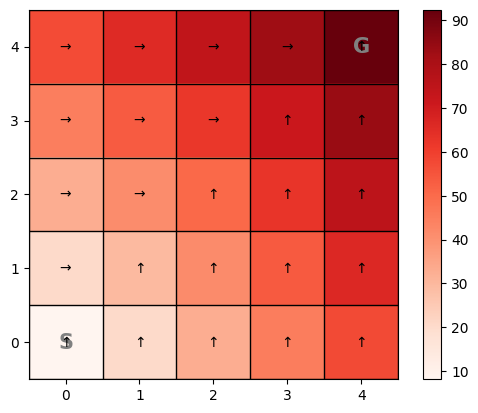

In [715]:
w = semi_gradient_Sarsa(env, n=100, epsilon=0.1, alpha=0.001, gamma=1, verbose=False)
Q, V, pol = plot_w(w)

Even a very small number of sampled episodes is enough to learn a value function that leads to a good policy.

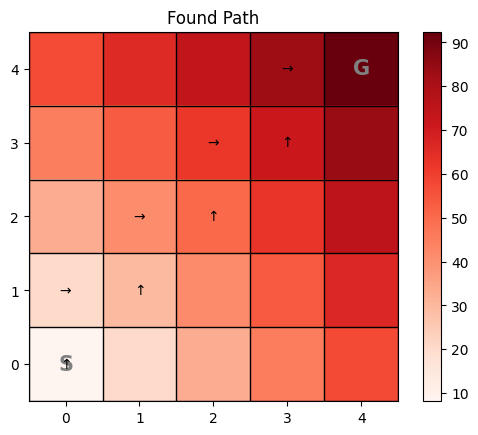

In [716]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol, max_len=100)
env.image(V, policy=pol, episode=path, title='Found Path')

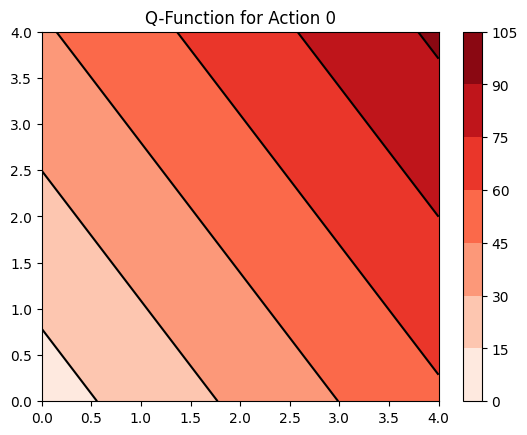

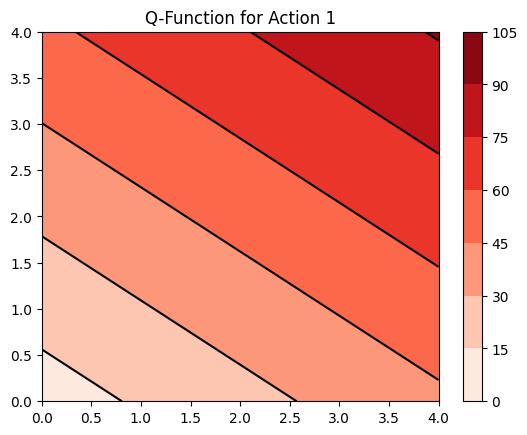

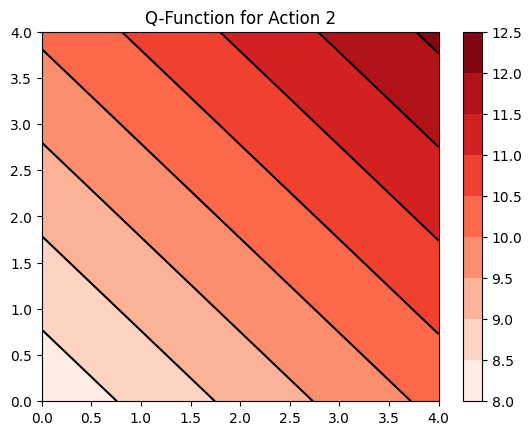

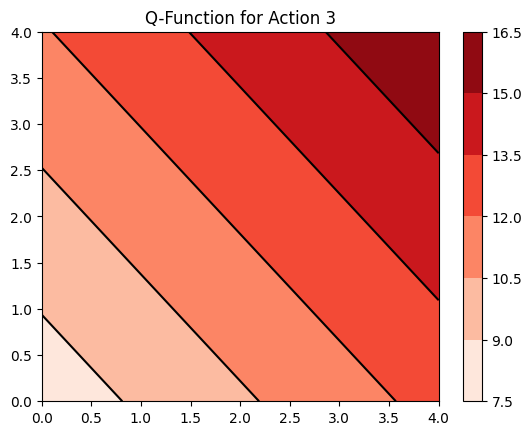

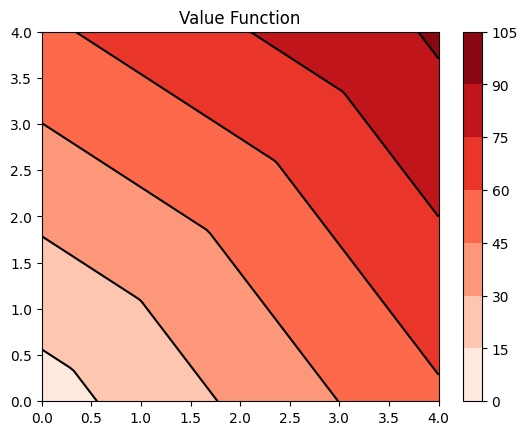

In [717]:
from matplotlib import pyplot as plt

def q_hat_grid(x, y, a, w):
    return np.dot(w[active_weights(a)], [1, x, y])

x = np.linspace(0, 4, 100)
y = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x, y)

# plot the Q-function for each action
for a in range(env.action_space.n):
    Z = np.array([q_hat_grid(x, y, a, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

    plt.contourf(X, Y, Z, cmap='Reds')
    plt.colorbar()
    plt.title(f'Q-Function for Action {a}')
    plt.contour(X, Y, Z, colors='black') # Contour lines
    plt.show()
    
# plot the value function
Z = np.array([np.max([q_hat_grid(x, y, a, w) for a in range(env.action_space.n)]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
plt.contourf(X, Y, Z, cmap='Reds')
plt.colorbar()
plt.title('Value Function')
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()

Let's compare the learned value function with it with the optimal value function. Since we have model access, we can calculate it using value iteration.

In [718]:
from gym_classics.algorithms.dynamic_programming import value_iteration
V_true = value_iteration(env, discount = 1)
V_true 

array([ 93.,  94.,  95.,  96.,  97.,  94.,  95.,  96.,  97.,  98.,  95.,
        96.,  97.,  98.,  99.,  96.,  97.,  98.,  99., 100.,  97.,  98.,
        99., 100., 100.])

Here is the learned value function implied in the approximate Q-value function.

In [719]:
V

array([ 8.12, 20.37, 32.61, 44.86, 57.11, 20.46, 29.23, 41.13, 53.38,
       65.63, 32.8 , 41.57, 50.34, 61.89, 74.14, 45.14, 53.91, 62.68,
       71.45, 82.65, 57.48, 66.25, 75.02, 83.79, 92.46])

The mean square value error measures the error of a value function given the true value function. It is typically weighted by how likely it is for the agent to be in a state (i.e., the stationary on-policy state distribution $\mu(s)$).

In [720]:
# mean squared value error. For the measure, the error for each state is typically weighted by how often it occurs.
# If no weight vector is given then we calculate the unweighted error.
def MSVE(V, V_true, weight=None):
    if weight is None:
        weight = np.ones(len(V))
    
    return np.sum(weight * (V - V_true)**2)

Let's estimate $\mu(s)$ via sampling. Note: If we have model access then we could also directly calculate the distribution (see textbook).

In [721]:
def on_policy_state_distribution(env, pol, epsilon = 0, n = 1):
    episodes = np.concat([sample_episode(env, policy=pol, epsilon = epsilon) for _ in range(n)])
    states = episodes[:,0]
    state_cnts = np.array([list(states).count(s) for s in range(env.observation_space.n)])
    state_prob = state_cnts / sum(state_cnts)
    return state_prob

In [722]:
state_prob = on_policy_state_distribution(env, pol, epsilon = .1, n = 100)
state_prob

array([0.12, 0.12, 0.01, 0.  , 0.  , 0.01, 0.12, 0.12, 0.01, 0.  , 0.  ,
       0.  , 0.11, 0.12, 0.01, 0.  , 0.  , 0.01, 0.12, 0.12, 0.  , 0.  ,
       0.  , 0.  , 0.  ])

In [723]:
msve = MSVE(V, V_true, weight=state_prob)
msve_sqrt = np.sqrt(msve)

print(f"MSVE: {msve}, sqrt(MSVE): {msve_sqrt}")

MSVE: 3034.78958143964, sqrt(MSVE): 55.08892430824585


The error is extremely high. The reason is that we learned with a very small number of episodes and a low learning rate. 

### Experiment With Learning

In [724]:
w = np.zeros(9)
w_list = []

for _ in range(10000):
    w = semi_gradient_Sarsa(env, n=1, epsilon=0.1, alpha=0.0001, gamma=1, w = w, verbose=False)
    w_list.append(w.copy())

display(w_list)

[array([ 0.01, -0.  , -0.  ,  0.03,  0.04, -0.  , -0.  , -0.  , -0.  ]),
 array([-0.  , -0.  , -0.  , -0.01,  0.03, -0.  , -0.  , -0.  , -0.  ]),
 array([-0.  ,  0.03,  0.03, -0.03,  0.02, -0.01, -0.  , -0.01, -0.  ]),
 array([ 0.  ,  0.03,  0.01,  0.  ,  0.06, -0.01, -0.01, -0.01, -0.  ]),
 array([ 0.01,  0.07,  0.04, -0.  ,  0.06, -0.01, -0.01, -0.01, -0.  ]),
 array([ 0.01,  0.05,  0.01,  0.03,  0.09, -0.01, -0.01, -0.01, -0.01]),
 array([ 0.02,  0.09,  0.04,  0.  ,  0.08, -0.01, -0.01, -0.01, -0.01]),
 array([ 0.02,  0.08,  0.02,  0.03,  0.12, -0.01, -0.01, -0.01, -0.01]),
 array([ 0.03,  0.12,  0.05,  0.03,  0.11, -0.01, -0.01, -0.01, -0.01]),
 array([ 0.04,  0.11,  0.05,  0.06,  0.15, -0.01, -0.01, -0.01, -0.01]),
 array([ 0.04,  0.15,  0.08,  0.06,  0.15, -0.01, -0.01, -0.01, -0.01]),
 array([ 0.05,  0.15,  0.08,  0.09,  0.19, -0.01, -0.01, -0.01, -0.01]),
 array([ 0.06,  0.19,  0.11,  0.07,  0.18, -0.01, -0.01, -0.01, -0.01]),
 array([ 0.07,  0.19,  0.1 ,  0.1 ,  0.22, -0.01, -

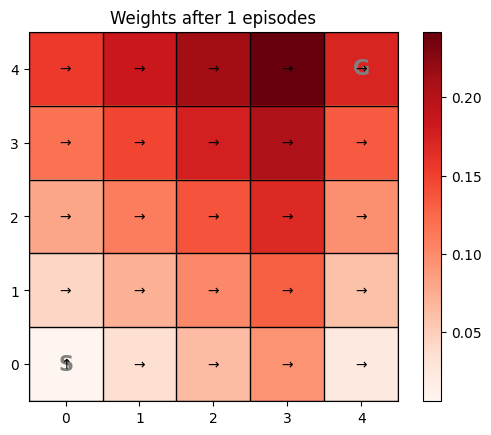

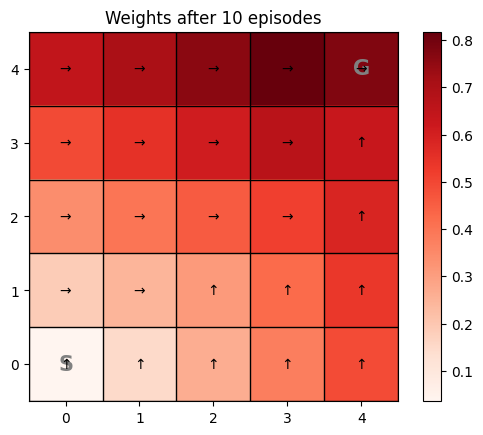

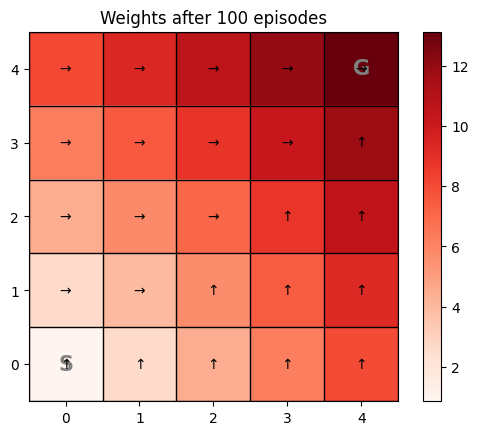

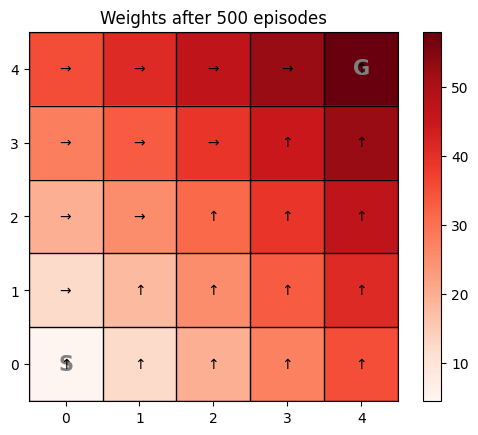

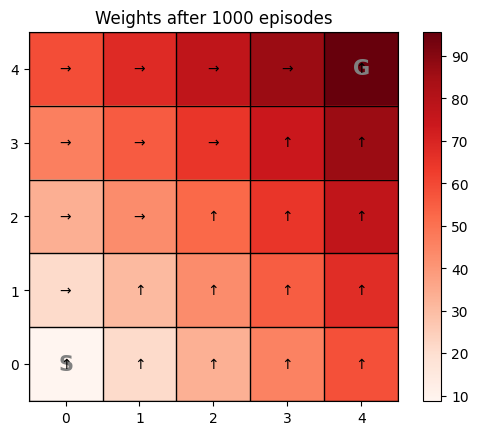

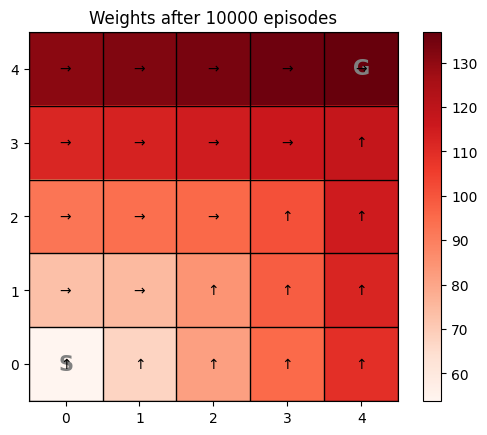

In [725]:
for i in [0,9, 99, 499, 999, 9999]:
    Q, V, pol = plot_w(w_list[i], title=f"Weights after {i+1} episodes")    

Look at MSVE over episodes.

In [726]:
def MSVE_w(w, weight=None):
    Q = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    V = np.max(Q, axis=1)
    return MSVE(V, V_true, weight=weight)  

all_but_final_state = [1]*(env.observation_space.n-1)+[0]

msve = [MSVE_w(w, weight=all_but_final_state) for w in w_list]

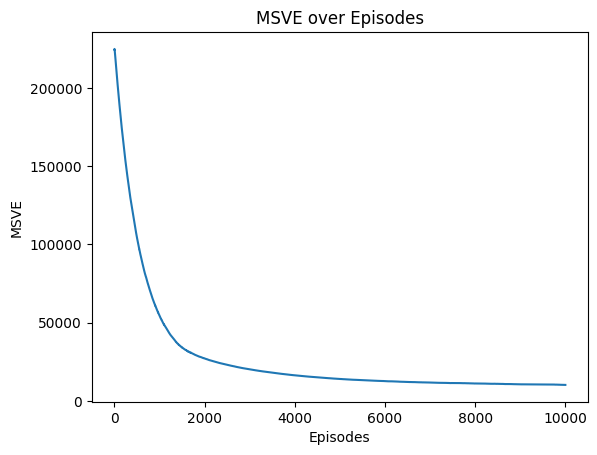

In [727]:
import matplotlib.pyplot as plt 

# plot MSVE over episodes
plt.plot(msve)
plt.xlabel('Episodes')
plt.ylabel('MSVE')
plt.title('MSVE over Episodes')
plt.show()


Too large learning rate will destabilize the estimation over time!

# Change Learning Rate Over Time

For gradient descent methods,
it is a good idea to reduce the learning rate over time.

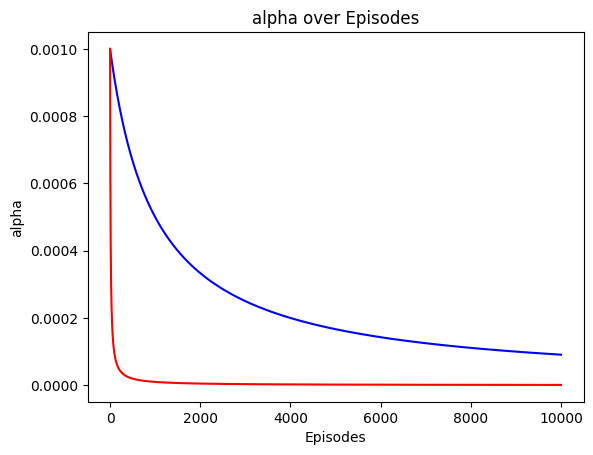

In [728]:
def schedule(episode, value_0=0.001, k=0.001):
    return value_0 / (1 + k * episode)

plt.plot([schedule(i, 0.001, 0.001) for i in range(10000)], color = "blue")
plt.plot([schedule(i, 0.001, 0.1) for i in range(10000)], color = "red")
plt.xlabel('Episodes')
plt.ylabel('alpha')
plt.title('alpha over Episodes')
plt.show()

In [779]:
w = np.zeros(9)
w_list = []

for i in range(10000):
    #w = semi_gradient_Sarsa(env, n=1, epsilon=schedule(i, value_0=0.1, k=0.01), alpha=schedule(i, value_0=0.001, k=0.001), gamma=1, w = w, verbose=False)
    #w = semi_gradient_Sarsa(env, n=1, epsilon=schedule(i, value_0=0.5, k=0.001), alpha=schedule(i, value_0=0.001, k=0.001), gamma=1, w = w, verbose=False)
    #w = semi_gradient_Sarsa(env, n=1, epsilon=.1, alpha=schedule(i, value_0=0.001, k=0.01), gamma=1, w = w, verbose=False)
    w = semi_gradient_Sarsa(env, n=1, epsilon=schedule(i, value_0=0.5, k=0.01), alpha=0.0001, gamma=1, w = w, verbose=False)
    w_list.append(w.copy())

display(w_list)

[array([-0.01, -0.  , -0.01, -0.  , -0.01, -0.  , -0.01, -0.  , -0.01]),
 array([-0.01,  0.03,  0.02, -0.01, -0.01, -0.01, -0.01, -0.01, -0.01]),
 array([-0.02,  0.03, -0.  , -0.01, -0.01, -0.01, -0.02, -0.01, -0.01]),
 array([-0.01,  0.03, -0.02,  0.02,  0.03, -0.01, -0.02, -0.01, -0.01]),
 array([-0.01,  0.06,  0.01,  0.02,  0.02, -0.01, -0.02, -0.01, -0.01]),
 array([ 2.67e-05,  6.00e-02,  6.92e-03,  4.61e-02,  6.26e-02, -1.12e-02,
        -1.88e-02, -9.55e-03, -1.53e-02]),
 array([ 0.01,  0.1 ,  0.04,  0.04,  0.06, -0.01, -0.02, -0.01, -0.02]),
 array([ 0.01,  0.09,  0.03,  0.07,  0.1 , -0.01, -0.02, -0.01, -0.02]),
 array([ 0.02,  0.13,  0.06,  0.07,  0.1 , -0.01, -0.02, -0.01, -0.02]),
 array([ 0.03,  0.13,  0.05,  0.1 ,  0.13, -0.01, -0.02, -0.01, -0.02]),
 array([ 0.03,  0.16,  0.08,  0.09,  0.13, -0.02, -0.02, -0.01, -0.02]),
 array([ 0.04,  0.16,  0.08,  0.12,  0.17, -0.02, -0.02, -0.01, -0.02]),
 array([ 0.05,  0.2 ,  0.11,  0.11,  0.16, -0.02, -0.02, -0.01, -0.02]),
 array(

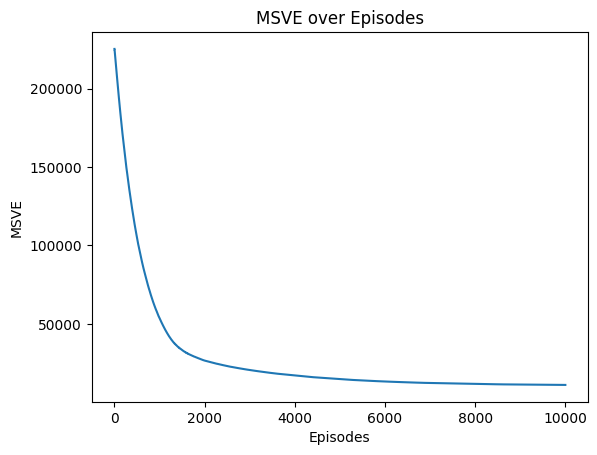

In [780]:
msve = [MSVE_w(w, all_but_final_state) for w in w_list]

plt.plot(msve)
plt.xlabel('Episodes')
plt.ylabel('MSVE')
plt.title('MSVE over Episodes')
plt.show()

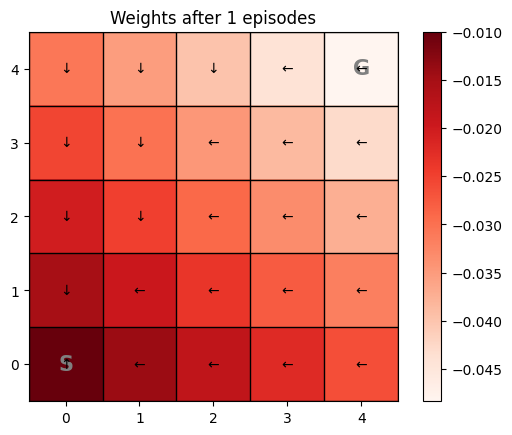

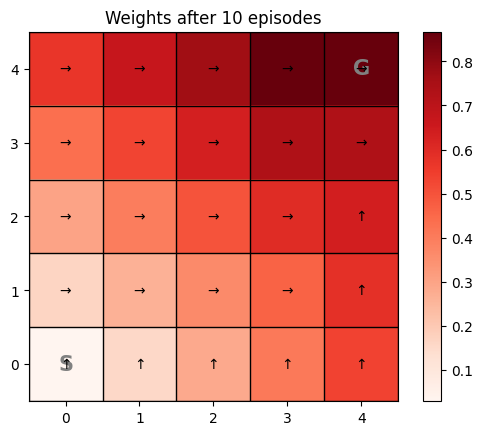

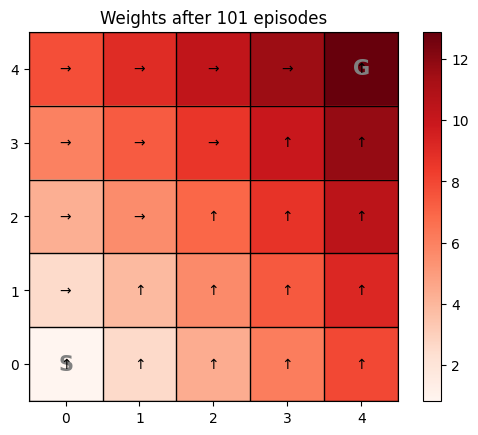

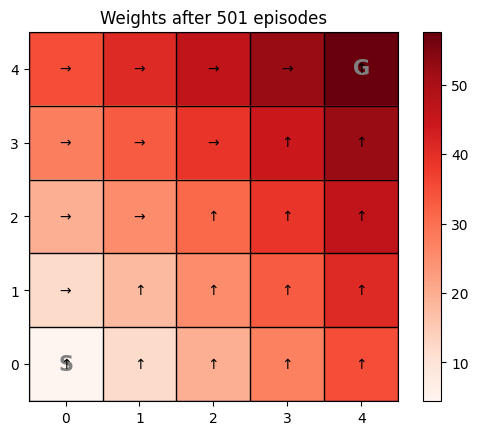

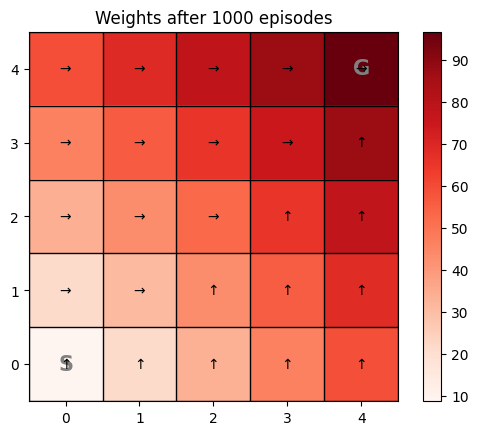

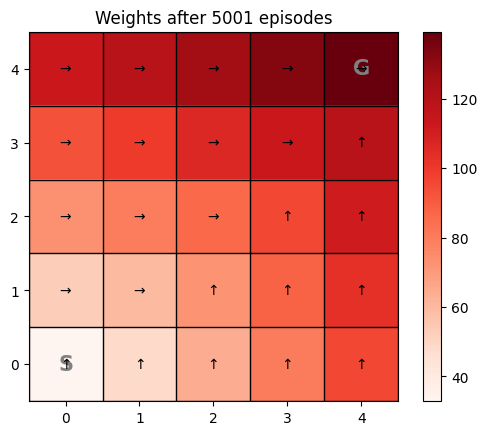

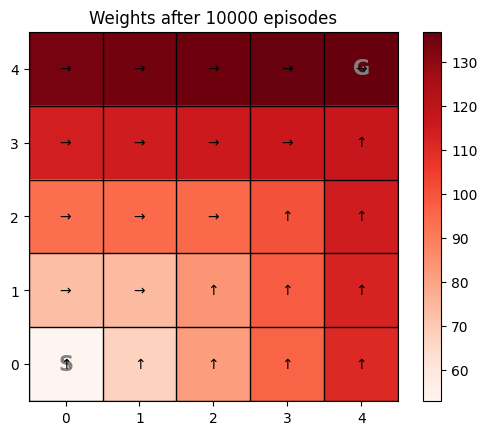

In [781]:
for i in [0, 9, 100, 500, 999, 5000, 9999]:
    Q, V, pol = plot_w(w_list[i], title=f"Weights after {i+1} episodes")  

Note: The last episode creates a valid optimal policy. All paths from S to G are optimal in this simple setting!

Let's calculate the MSVE for the on-policy state distribution for the final approximation.

array([52.93, 14.37,  2.09,  0.69, 20.33,  6.87,  5.33,  7.31,  5.78])

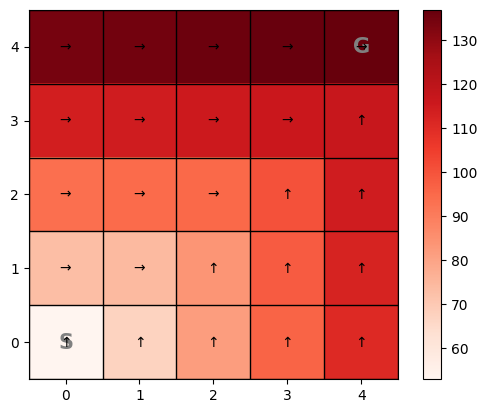

array([0.12, 0.12, 0.  , 0.  , 0.  , 0.  , 0.12, 0.  , 0.  , 0.  , 0.  ,
       0.12, 0.12, 0.  , 0.  , 0.  , 0.  , 0.12, 0.12, 0.  , 0.  , 0.  ,
       0.  , 0.12, 0.  ])

'Compare state values of visited states.'

array([ 52.93,  73.27,  73.96,  83.76,  94.99, 100.22, 116.02, 116.68])

array([ 93.,  94.,  95.,  96.,  97.,  98.,  99., 100.])

'weighted MSVE'

np.float64(400.518028424554)

In [782]:
w = w_list[-1]
display(w)

Q, V, pol = plot_w(w)
#display(Q)

state_prob = on_policy_state_distribution(env, pol, epsilon = 0, n = 1)
display(state_prob)

display("Compare state values of visited states.")
display(V[state_prob>0])
display(V_true[state_prob>0])

display("weighted MSVE")
display(MSVE(V, V_true, weight=state_prob))

I reduce epsilon to estimate a policy close to the deterministic policy.
Note: Play with `value_0` and `k` to see how instable learning is! 


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)